In [297]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot  as plt
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier)
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import (cross_val_score, StratifiedKFold, GridSearchCV)
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, RocCurveDisplay, ConfusionMatrixDisplay

In [298]:
np.random.seed(42)

dataset = pd.read_csv("dataset_heart_attack.csv")

print("shape : ", dataset.shape)

shape :  (294, 14)


In [299]:
dataset

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,28,1,2,130,132,0,2,185,0,0.0,?,?,?,0
1,29,1,2,120,243,0,0,160,0,0.0,?,?,?,0
2,29,1,2,140,?,0,0,170,0,0.0,?,?,?,0
3,30,0,1,170,237,0,1,170,0,0.0,?,?,6,0
4,31,0,2,100,219,0,1,150,0,0.0,?,?,?,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
289,52,1,4,160,331,0,0,94,1,2.5,?,?,?,1
290,54,0,3,130,294,0,1,100,1,0.0,2,?,?,1
291,56,1,4,155,342,1,0,150,1,3.0,2,?,?,1
292,58,0,2,180,393,0,0,110,1,1.0,2,?,7,1


In [300]:
# ca, thal et slope ont respectivement 99%, 90.5% et 64.6% de valeurs manquantes :
# trop incomplètes pour être imputées de façon fiable, on les supprime.
# Les autres colonnes ont moins de 8% de NaN : elles seront imputées dans le pipeline.
dataset = dataset.drop(columns=["slope", "ca", "thal"])
dataset = dataset.drop_duplicates()
dataset

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,num
0,28,1,2,130,132,0,2,185,0,0.0,0
1,29,1,2,120,243,0,0,160,0,0.0,0
2,29,1,2,140,?,0,0,170,0,0.0,0
3,30,0,1,170,237,0,1,170,0,0.0,0
4,31,0,2,100,219,0,1,150,0,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...
289,52,1,4,160,331,0,0,94,1,2.5,1
290,54,0,3,130,294,0,1,100,1,0.0,1
291,56,1,4,155,342,1,0,150,1,3.0,1
292,58,0,2,180,393,0,0,110,1,1.0,1


In [301]:
print("shape of dataset: ", dataset.shape)
print("Colonnes dupliquées", dataset.duplicated().sum())

shape of dataset:  (293, 11)
Colonnes dupliquées 0


In [302]:
print("DATASET INFO")
dataset.info()

DATASET INFO
<class 'pandas.DataFrame'>
Index: 293 entries, 0 to 293
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   age         293 non-null    int64  
 1   sex         293 non-null    int64  
 2   cp          293 non-null    int64  
 3   trestbps    293 non-null    str    
 4   chol        293 non-null    str    
 5   fbs         293 non-null    str    
 6   restecg     293 non-null    str    
 7   thalach     293 non-null    str    
 8   exang       293 non-null    str    
 9   oldpeak     293 non-null    float64
 10  num         293 non-null    int64  
dtypes: float64(1), int64(4), str(6)
memory usage: 31.1 KB


In [303]:
dataset.describe()

,age,sex,cp,oldpeak,num
count,293.000000,293.000000,293.000000,293.000000,293.000000
mean,47.822526,0.726962,2.986348,0.588055,0.361775
std,7.824875,0.446282,0.965049,0.909554,0.481336
min,28.000000,0.000000,1.000000,0.000000,0.000000
25%,42.000000,0.000000,2.000000,0.000000,0.000000
50%,49.000000,1.000000,3.000000,0.000000,0.000000
75%,54.000000,1.000000,4.000000,1.000000,1.000000
max,66.000000,1.000000,4.000000,5.000000,1.000000


In [304]:
dataset.columns = dataset.columns.str.strip()
print(dataset.columns.tolist())

['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'num']


In [305]:
dataset.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,num
0,28,1,2,130,132,0,2,185,0,0.0,0
1,29,1,2,120,243,0,0,160,0,0.0,0
2,29,1,2,140,?,0,0,170,0,0.0,0
3,30,0,1,170,237,0,1,170,0,0.0,0
4,31,0,2,100,219,0,1,150,0,0.0,0


In [306]:
dataset = dataset.replace("?", np.nan)
dataset

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,num
0,28,1,2,130,132,0,2,185,0,0.0,0
1,29,1,2,120,243,0,0,160,0,0.0,0
2,29,1,2,140,NaN,0,0,170,0,0.0,0
3,30,0,1,170,237,0,1,170,0,0.0,0
4,31,0,2,100,219,0,1,150,0,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...
289,52,1,4,160,331,0,0,94,1,2.5,1
290,54,0,3,130,294,0,1,100,1,0.0,1
291,56,1,4,155,342,1,0,150,1,3.0,1
292,58,0,2,180,393,0,0,110,1,1.0,1


In [307]:
for col in dataset.columns:
    dataset[col] = pd.to_numeric(dataset[col], errors="coerce")

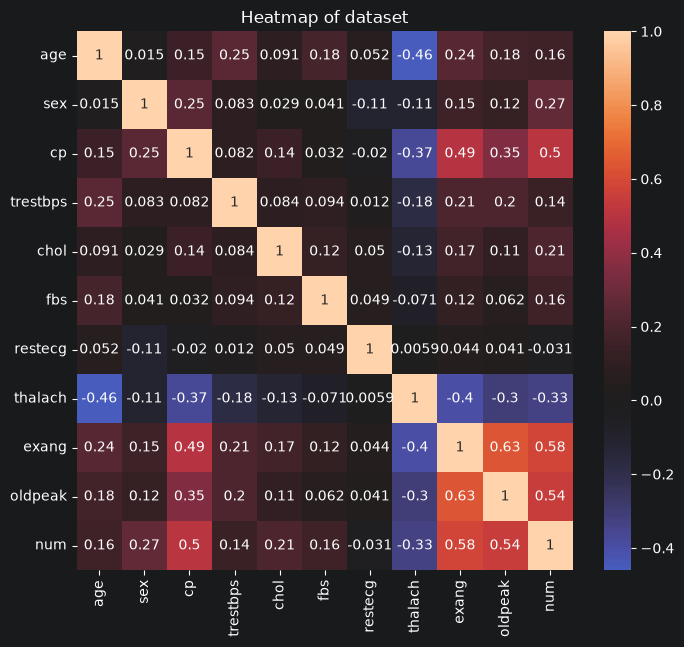

In [308]:
plt.figure(figsize=(8,7))
numeric_features = dataset.select_dtypes(include="number")
corr_matrix = numeric_features.corr()
sns.heatmap(corr_matrix, center=0, annot=True)
plt.title("Heatmap of dataset")
plt.show()

In [309]:
X = dataset.drop(columns="num")
y = dataset["num"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

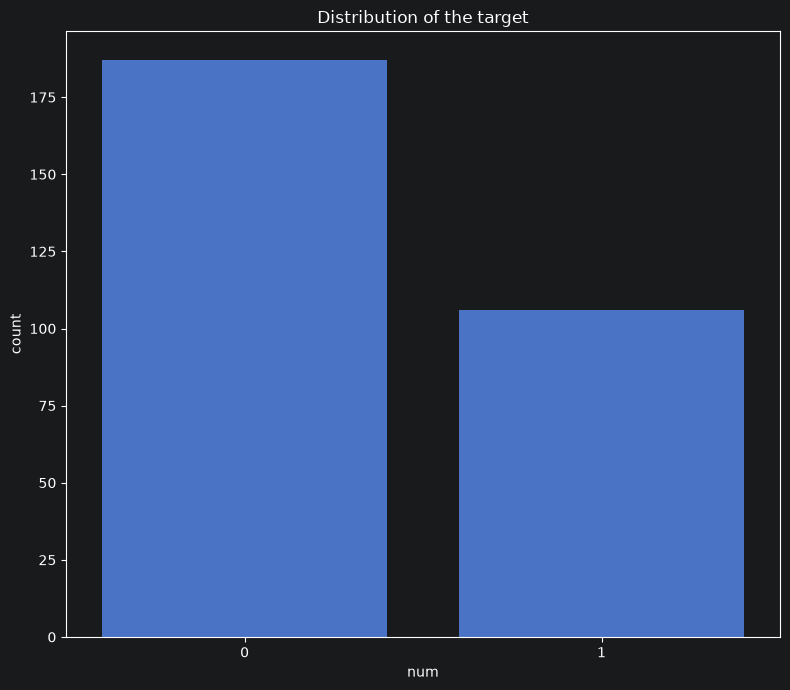

In [310]:
plt.figure(figsize=(8,7))
sns.countplot(data=dataset,x="num")
plt.title("Distribution of the target")
plt.tight_layout()
plt.show()

In [311]:
## On remarque que la répartition des données de la cible comportent un léger désequilibre.

In [312]:
dataset.skew()

age        -0.282281
sex        -1.024116
cp         -0.225827
trestbps    0.737336
chol        1.433386
fbs         3.383166
restecg     1.977815
thalach    -0.080368
exang       0.852514
oldpeak     1.543805
num         0.578287
dtype: float64

In [313]:
columns_num = X_train.select_dtypes(include="number").columns.tolist()
columns_cat = X_train.select_dtypes(include="object").columns.tolist()

In [314]:
pipeline_num = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

pipeline_cat = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", pipeline_num, columns_num),
    ("cat", pipeline_cat, columns_cat)
])

In [315]:
baseline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(baseline, X_train, y_train, cv=cv, scoring="f1")
print(f"Logistic Regression F1 score: {scores.mean():.3f} (+/- {scores.std():.3f})")

Logistic Regression F1 score: 0.767 (+/- 0.059)


In [316]:
models = {
    "Gradient Boosting Classifier": GradientBoostingClassifier(random_state=42) ,
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
    }

In [317]:
resultats = []

for name, model in models.items():
    pipe = Pipeline([("preprocessor", preprocessor), ("model", model)])
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="f1", n_jobs=-1)
    resultats.append({"model": name, "f1_mean": scores.mean(), "f1_std": scores.std()})
    print(f"{name} F1 score: {scores.mean():.3f} +/- {scores.std():.3f}")


Gradient Boosting Classifier F1 score: 0.686 +/- 0.064
Random Forest F1 score: 0.734 +/- 0.054


In [318]:
dummy = Pipeline([
    ("preprocessor", preprocessor),
    ("model", DummyClassifier(strategy="most_frequent"))
])

scores = cross_val_score(dummy, X_train, y_train, cv=cv, scoring="f1")

print(f"DummyClassifier: {scores.mean():.3f} +/- {scores.std():.3f}")

DummyClassifier: 0.000 +/- 0.000


In [321]:
param_grid = {
    "model__C" : [0.01,0.1,1,10],
}

grid = GridSearchCV(baseline, param_grid=param_grid, cv=cv,scoring="f1", n_jobs=-1)
grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step..._iter=1000))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__C': [0.01, 0.1, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of information p

In [322]:
print("Meilleurs paramètres :", grid.best_params_)
print("Meilleur score F1 (CV) :", grid.best_score_)

Meilleurs paramètres : {'model__C': 1}
Meilleur score F1 (CV) : 0.7675


              precision    recall  f1-score   support

           0       0.81      0.89      0.85        38
           1       0.76      0.62      0.68        21

    accuracy                           0.80        59
   macro avg       0.79      0.76      0.77        59
weighted avg       0.79      0.80      0.79        59



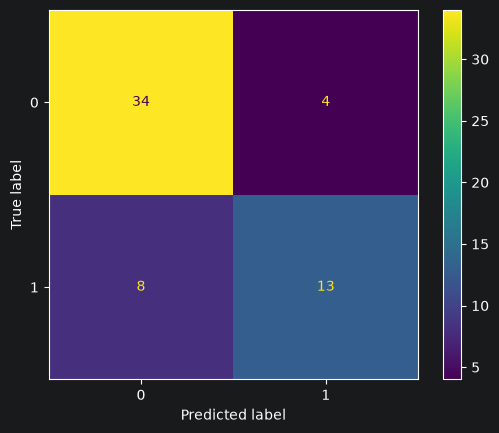

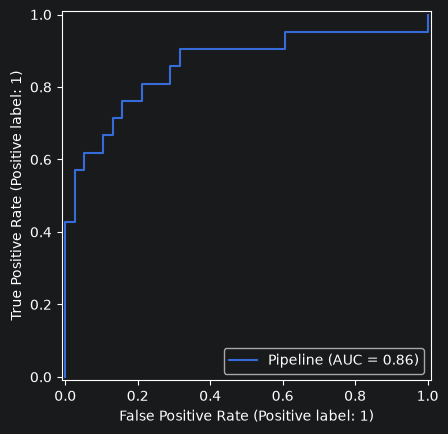

In [320]:
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)
print(classification_report(y_test, y_pred))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
RocCurveDisplay.from_estimator(best_model, X_test, y_test)